Distance, transport and gradient between two large point clouds
===============================================================

**When to use:** you have two point clouds of ten thousand points or more and want to know how far apart they
are, where the transport sends each point, and how to move the first cloud to reduce the distance.

**What you will see:** the Sinkhorn divergence and the entropic OT cost between two clouds of 100,000 points,
their dual potentials, the transport plan applied without ever forming its 100,000 x 100,000 matrix, and the
gradient, each with its time and memory. For the notions themselves (transport plan, blur, debiasing), see the
GeomLoss gallery: https://www.kernel-operations.io/geomloss/_auto_examples/index.html

Source: [plot_sinkhorn_basics.py](plot_sinkhorn_basics.py) · [Gallery](../README.md)

Reference figures and quoted results come from previous script runs. They are reading aids, not outputs from an execution of this notebook.

Install `pip install --upgrade 'flash-sinkhorn[notebooks]'`, clone this repository for the example files, and start `jupyter lab` from the checkout. Select its Python environment, then run the cells in order on an NVIDIA CUDA GPU. The setup cell finds the checkout from the repository root or this notebook's folder. The solver comes from the installed package. Running all cells prints fresh results and displays new figures; it also replaces the source's saved images. The scale examples retain the script's full problem sizes.

In [ ]:
# Find this checkout when Jupyter starts at its root or in a notebook folder.
import os
import sys
from pathlib import Path

for _candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_candidate / 'examples/getting_started/plot_sinkhorn_basics.py').is_file() and (_candidate / "torch-ext/flash_sinkhorn").is_dir():
        _notebook_root = _candidate
        break
else:
    raise RuntimeError("Start Jupyter inside the flash-sinkhorn repository checkout.")

os.chdir(_notebook_root)
# Locate shared example helpers; import the solver from the installed package.
for _path in reversed([_notebook_root / "examples", _notebook_root]):
    if str(_path) in sys.path:
        sys.path.remove(str(_path))
    sys.path.insert(0, str(_path))
__file__ = str(_notebook_root / 'examples/getting_started/plot_sinkhorn_basics.py')

# Display the saved PNG/GIF files explicitly, including figures closed by the source.
import matplotlib
matplotlib.use("Agg")

Setup
-----

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from flash_sinkhorn import SamplesLoss

sys.path.append(str(Path(__file__).resolve().parents[1]))  # the gallery's shared helpers
from _plotting import (SOURCE, TARGET, arrows, cloud, dense_size, fit_limits, images_dir, require_cuda,  # noqa: E402
                       save, small_multiples, subsample, timed, to_numpy)
from _transport import barycentric_targets, marginals  # noqa: E402

device = require_cuda()
torch.manual_seed(0)

Two clouds of 100,000 points
----------------------------
A Gaussian blob x and a noisy arc y, with uniform weights a and b.

In [ ]:
n = m = 100_000
x = 0.25 * torch.randn(n, 2, device=device) + torch.tensor([-0.8, 0.0], device=device)
theta = 1.2 + 2.6 * torch.rand(m, device=device)
y = torch.stack([0.6 + 0.8 * torch.cos(theta), 0.8 * torch.sin(theta)], dim=1)
y = y + 0.04 * torch.randn(m, 2, device=device)
a = torch.full((n,), 1.0 / n, device=device)
b = torch.full((m,), 1.0 / m, device=device)
print(dense_size(n, m))

The distance
------------
``half_cost=True`` uses the cost |x - y|^2 / 2, as GeomLoss does for ``p=2``; ``blur`` is the length scale of
the entropic smoothing, eps = blur^2. ``debias=True`` gives the Sinkhorn divergence S_eps, which vanishes when
the clouds coincide; ``debias=False`` gives the entropic OT cost OT_eps.

``autotune=False`` skips the benchmarking of kernel configurations that the default ``autotune=True`` runs, in
every new process, the first time it meets a new size bucket, dimension or precision. Tuning pays off when one
size is solved many times, as in a training loop; for the few solves of a script like this one it costs more
than it saves. Kernels are still compiled, or loaded from Triton's disk cache, on first use.

In [ ]:
blur = 0.05
divergence = SamplesLoss(blur=blur, half_cost=True, debias=True, backend="symmetric", autotune=False)
entropic_ot = SamplesLoss(blur=blur, half_cost=True, debias=False, backend="symmetric", autotune=False)
s_eps = timed("S_eps(x, y)", lambda: divergence(a, x, b, y))
ot_eps = timed("OT_eps(x, y)", lambda: entropic_ot(a, x, b, y))
print(f"S_eps(x, y) = {s_eps.item():.5f}, OT_eps(x, y) = {ot_eps.item():.5f}")

The transport, without the n x m plan
-------------------------------------
``potentials=True`` returns the dual potentials f and g of OT_eps (use ``debias=False``). They define the plan
P = diag(a) exp((f + g - C) / eps) diag(b), and streaming kernels apply it in memory linear in n + m: here its
marginals P 1 and P'1, and the barycentric targets (P y) / (P 1), the average position each source point is
sent to. ``examples/_transport.py`` shows the conversion to the kernels' conventions.

The plan needs a more careful solve than the loss. The default schedule (``scaling=0.5``) is fast and serves
the loss and its gradient, but it stops long before P 1 = a and P'1 = b hold. A slower schedule
(``scaling=0.95``) gets much closer, in strict FP32. Default TF32 rounds the centred coordinates before
evaluating costs; reconstructing the plan on the original points can therefore leave a marginal error.

In [ ]:
careful = SamplesLoss(blur=blur, half_cost=True, debias=False, backend="symmetric", potentials=True,
                      scaling=0.95, allow_tf32=False, autotune=False)
f, g = timed("potentials, scaling=0.95, FP32", lambda: careful(a, x, b, y))
row, col = marginals(x, y, f, g, a, b, eps=blur**2, cost_scale=0.5)
print(f"|P 1 - a|_1 = {(row - a).abs().sum().item():.2e}, |P'1 - b|_1 = {(col - b).abs().sum().item():.2e}")
targets = timed("barycentric targets", lambda: barycentric_targets(x, y, f, g, a, b, eps=blur**2,
                                                                   cost_scale=0.5))

The gradient
------------
Autograd differentiates the loss with respect to the points. Divided by the weights, -grad_x S_eps points
where each source point should move; with the half cost it is close to the arrow from x_i to its barycentric
target.

In [ ]:
def gradient():
    z = x.clone().requires_grad_(True)
    grad, = torch.autograd.grad(divergence(a, z, b, y), z)
    return grad


displacement = -timed("gradient of S_eps", gradient) / a[:, None]

Figure
------
All 200,000 points coloured by their potential; arrows for 100 random source points.

In [ ]:
idx = subsample(n, 100, device=device)
span = torch.cat([x, y]).amax(dim=0) - torch.cat([x, y]).amin(dim=0)
fig, axes = small_multiples(1, 3, size=4.0, aspect=(span[1] / span[0]).item())
ax_pot, ax_map, ax_grad = axes[0]
values = torch.cat([f, g])
vmin, vmax = values.min().item(), values.max().item()
for points, potential in ((x, f), (y, g)):
    p = to_numpy(points)
    image = ax_pot.scatter(p[:, 0], p[:, 1], c=to_numpy(potential), s=0.3, cmap="viridis", vmin=vmin, vmax=vmax,
                           edgecolors="none", rasterized=True)
fig.colorbar(image, ax=ax_pot, fraction=0.046, pad=0.02)
ax_pot.set_title("potentials f on x, g on y")
for ax in (ax_map, ax_grad):
    cloud(ax, y, TARGET)
    cloud(ax, x, SOURCE)
arrows(ax_map, x[idx], targets[idx] - x[idx])
fit_limits(ax_map, x, y, targets[idx])
ax_map.set_title("to the barycentric targets")
arrows(ax_grad, x[idx], displacement[idx])
fit_limits(ax_grad, x, y, x[idx] + displacement[idx])
ax_grad.set_title("-grad S_eps / a")
save(fig, images_dir(__file__), "basics")
plt.show()

In [ ]:
from IPython.display import Image as _NotebookImage, display as _notebook_display
_notebook_display(_NotebookImage(filename=str(_notebook_root / 'examples/getting_started/images/basics.png')))
# Release figure managers so repeated runs do not accumulate open figures.
import matplotlib.pyplot as _notebook_plt
_notebook_plt.close("all")

**Reference figure from previous script runs.**

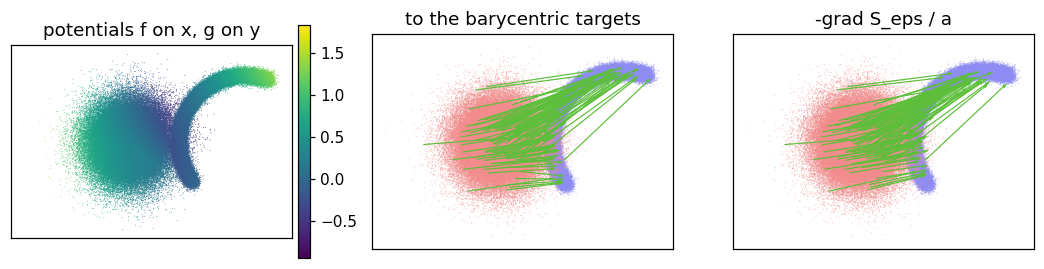